# BEE 4750 Homework 1: Introduction to Using Julia

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [106]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\holly\4750 HW\bee4750-hw1-ella-sandwich`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [104]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [105]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

The initial minimum value at 0 was the issue, seeing as if you have all values in your array above 0, none will be the min. You have to start it as high as you can, which is why i chose infinity, and bring it down from there. 

In [6]:
function minimum(array)
    # initialize the minimum value counter
    min_value = Inf64
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

The error means that the variable "average_grade" is undefined. The function was not called, so average_grade was undefined. After calling the function and setting it equal to "Average", it takes the correct value.

In [28]:
# enter student grade vector
grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average

using Statistics
function class_average(student_grades)
  average_grade = mean(student_grades)
  return average_grade
end

Average = class_average(grades)

94.4

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

MethodError means that the wrong arguments were given to a function, built-in or created by you. I redid some of the function organization so it made more sense to me, and discovered that the "outcomes" array was incorrectly made. Changing it to read "zeros(n_trials)" creates an array of 0s that can be changed depending on win/loss. 

In [44]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    sum_roll = sum(passadieci())
    if sum_roll >= 11
        outcomes[i] = 1
    #else
    #    outcomes[i] = 0
    end
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.492


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

This current code is attempting to subtract one value from a vector, so the method does not make sense. 
You have to instead go through the entire vector and individually subtract from each index. I programmed my function to do just that, and the error message went away. When testing on different vectors, there is sometimes an error regarding repeating decimals (3.33333...), but after rounding the mean the message disappeared and the code worked perfectly. 

In [53]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = (compute_mean(vect)) # compute mean
    # return demeaned vector
    for i in 1:length(vect)
        vect[i] = vect[i] - m
    end
    return vect 
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [0.37317987893195814, -0.06289375848122813, -0.16925379463472623, 0.3167102214503681, -0.009825368803801915, -0.25376600997075616, -0.2201098293177176, -0.39012691419794787, -0.05558350407567336, -0.2733029743084483, -0.4645349229352186, 0.47046688043620877, -0.3225437959866101, -0.18638805234321698, -0.47123262194409776, -0.33389349212570507, 0.47096821858994675, -0.17894830659946048, -0.3841373554967804, 0.02156737365284589, -0.46883088365020076, 0.12939239627284638, 0.053195201953165405, -0.3095023767124939, 0.37446519974086956, 0.42414993865047346, -0.03933059831929142, -0.046580682920559724, 0.3505243437184201, -0.04365239218152317, -0.06749154467051721, -0.47865214168574133, 0.3249745965301257, 0.07502504424339251, 0.23976887093346544, -0.11048297293546505, -0.19201696454877137, 0.44974026400668377, 0.27960254715412647, -0.2643685292104122, -0.4395261018132045, -0.14653879696690553, -0.2967290669502909, 0.30220067102553905, 0.48167652927868176, -0.37357

1000-element Vector{Float64}:
  0.37317987893195814
 -0.06289375848122813
 -0.16925379463472623
  0.3167102214503681
 -0.009825368803801915
 -0.25376600997075616
 -0.2201098293177176
 -0.39012691419794787
 -0.05558350407567336
 -0.2733029743084483
  ⋮
 -0.44678376394334096
  0.22371617726689952
 -0.13397347221412714
 -0.34052540344364945
 -0.4205215650310934
 -0.1382104975688474
 -0.09287919547835377
 -0.4848112427361262
 -0.4384237932117363

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

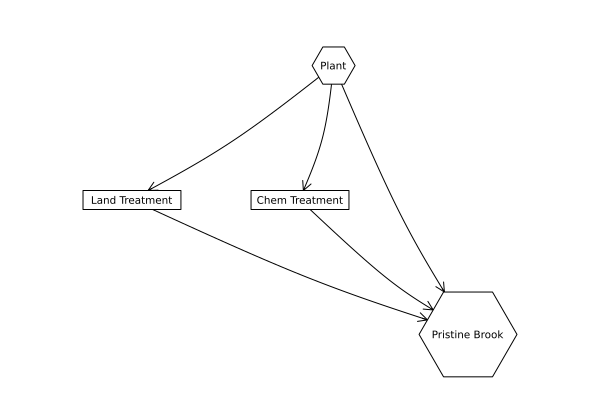

In [54]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => "", (1,3) => "", (1, 4) => "",(2, 4) => "",(3, 4) => "")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

There will be 3 equations coupled depending on X1, X2, and X3 (the discharge reaching each treatment), where resulting deposits in the brook are Y1, Y2, and Y3, summing together to result in the total deposit which must not exceed 20 kg/day
1: Y1 = X1 * 0.2;
2: Y2 = X2 - X2 * (1-0.005*X2);
3: Y3 = X3 * 1kg/m3;
(20 >= Y1 + Y2 + Y3), and X1+X2+X3 = 100

As for cost:
1: C1 = X1^2/20;
2: C2 = X2 * 1.5;
3: C3 = free;
Total cost = C1+C2+C3;

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

I created my function to take ratios for different treatment plans and convert those into actual outputs, including resulting deposited amount and resulting cost. As long as the ratios add up to less than 1.1 (not 1 due to rounding issues from certain numbers), the code will produce the resulting cost and deposited amount. 

In [118]:
function yuk_discharge(x1, x2, x3)
    if x1 + x2 + x3 > 1.1
        print("Incorrect Ratios")
    else
        # amount that reaches treatment facility based on given ratio
        X1 = x1 * 100
        X2 = x2 * 100
        X3 = x3 * 100
        # deposited amount in pristine brook
        Y1 = X1 * 0.2
        Y2 = X2 - (X2 * (1-(0.005*X2)))
        Y3 = X3 * 1
        # total deposited amount
        Y = Y1 + Y2 + Y3
        # cost
        C1 = (X1^2)/20
        C2 = X2 * 1.5
        C3 = 0
        # total cost 
        C = C1 + C2 + C3
    return (Y, C)
    end
end




yuk_discharge (generic function with 1 method)

In [159]:
# Function Test
Y, C = yuk_discharge(0.8, 0.2, 0)

(18.0, 350.0)

In [1]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10

To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [1]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]

2.3: 
In order to evaluate 1000 combinations, I created a matrix with 1000 columns and 3 rows, and normalized them to add up to 1. I then converted this matrix into 3 row-vectors, and evaluated all 1000 at the same timem using the broadcast feature explained above. There are a few combinations that are in compliance with the 20kg/day limit, but these are quite expensive. The cheapest one I see is around $275. As expected, the cheaper treatments result in more YUK discharge, and even the most expensive treatments may not satisfy the requirements. In order to find a better solution, I would like to have a budget, and maybe the importance of lowering the discharge numbers. The ranking of importance between cost and discharge amount would further hone in the combinations we should use. For example, if a lower YUK discharge is valued and cost is not a constraint, the combination with the lowest YUK discharge would win.  
2.4: 
In order to minimize cost, we should go fully with the cheapest option if YUK discharge is not considered. In this case, direct disposal is free and therefore cheaper than any other treatment option. This will result in a cost of $0, but a YUK discharge of 100m3/day * 1kg/m3 = 100 kg/day of YUK. As for minimizing YUK, we should only use the two options that actually remove the chemical (option 1 and option 2). Using the 2 equations we have for YUK disposal into the brook and the constraints Y1+Y2<20 and X1+X2=100, I combined the 2 equations to set an equation in terms in X2 equal to Y1+Y2, then finding the minimum of that equation, I found that X2=20 and therefore X1=80. This results in a deposited amount of 18 kg/day, which is consistent with the graph above. This solution will cost $350. These two points follow the pattern shown by the previous scatterplot, with the minimum YUK (18kg) being fairly close to other points of other combinations. However, there are other points on the plot that fall below the red dotted line that are cheaper. I would most likely go with these if I were on a budget, seeing as the deposited amount is still around the minimum value of 18kg. As for the minimum cost, it is a little more of an outlier, but still follows the pattern. I would certainly not go with this one, seeing as it serves no environmental benefit.

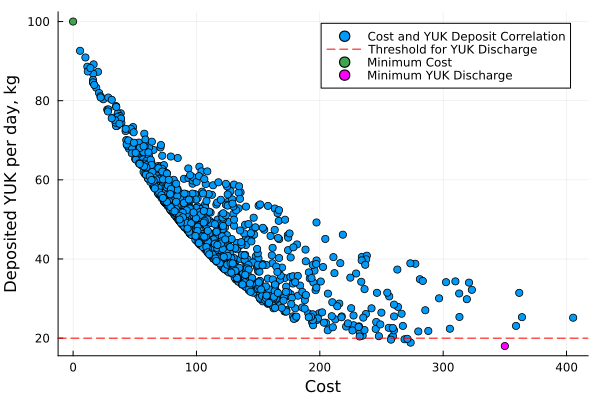

In [184]:
# 2.3
# random matrix generator
M = rand(3, 1000)
# make columns add up to 1
column_sums = sum(M, dims=1)
norm_M = M ./ column_sums
# create 3 vectors, which are the rows in matrix M
A = norm_M[1,:]
B = norm_M[2,:]
C = norm_M[3,:]
# Find output and Cost for each combo (x1000)
output = yuk_discharge.(A, B, C)
Y = [out[1] for out in output];
C = [out[2] for out in output];
@show Y
@show C

# Plot the results, with a line at y=20

import Pkg; 
Pkg.add("Plots")
plot(C, Y, seriestype=:scatter, xlabel = "Cost", ylabel = "Deposited YUK per day, kg", label="Cost and YUK Deposit Correlation", legend=:topright)
hline!(C, [20], linecolor=:red, linestyle=:dash, label="Threshold for YUK Discharge")

# Plot 2.4 values
min_cost_point = (0, 100)
min_yuk_point = (350, 18)
scatter!(min_cost_point, label="Minimum Cost")
scatter!(min_yuk_point, color=:magenta, label="Minimum YUK Discharge")




Make sure you comment your code appropriately to make it clear what is
going on and why.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

## References

List any external references consulted, including classmates.